In [148]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as special
from scipy.optimize import curve_fit
import seaborn as sns
from sklearn.metrics import r2_score
import pandas as pd

In [149]:
data = pd.read_csv('Belize_datoslimpios.csv')
data.head(5)

,Unnamed: 0,source,name,neighborhood_overview,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,...,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,0,city scrape,Mo's Cozy Cabana,The cabana is just a moments walk to 'The Spli...,Monique,03/07/10,Belize,within an hour,100%,90%,...,3.8,0.3,4.82,4.83,4.88,4.0,4.0,0.0,0.0,0.60
1,1,city scrape,"Seaside Villas 4 2nd Flr - Pool, Beach, Jacuzzi","Right on the beach, this building is in a prim...",Bobbi,19/05/11,"Belize City, Belize",within an hour,100%,100%,...,11.0,0.0,4.81,4.91,4.71,19.0,19.0,0.0,0.0,0.73
2,2,city scrape,Valarosa - Sweet cottage,Valarosa is on Avenida Chechem in a popular re...,Bobbi,19/05/11,"Belize City, Belize",within an hour,100%,100%,...,15.0,0.0,4.59,4.72,4.58,19.0,19.0,0.0,0.0,0.79
3,3,city scrape,"Toucan-kit, ac, wifi, bike, tropical gardens, ...","LOVE this area of Placencia; quiet, day & nigh...",Jacqueline Ann,23/06/11,"Placencia, Belize",within an hour,100%,100%,...,2.0,0.0,4.86,4.89,4.86,5.0,4.0,0.0,0.0,0.46
4,4,city scrape,rent a private room in a house,"Quiet neighbourhood, close to shopping centre,...",Jennifer,23/06/11,"Belmopan, Belize",a few days or more,0%,17%,...,1.0,0.0,4.58,4.92,4.83,1.0,0.0,1.0,0.0,0.11


In [150]:
# Limpiar columnas con formato string
data['host_response_rate'] = data['host_response_rate'].str.replace('%', '').astype(float)
data['host_acceptance_rate'] = data['host_acceptance_rate'].str.replace('%', '').astype(float)
data['price'] = data['price'].str.replace('[$,]', '', regex=True).astype(float)

In [151]:
# Definir modelo 1: cuadrático multiplicado (func1)
def func1(x, a, b, c):
    return ((a * x**2 + b) / c) * x

# Definir modelo 2: exponencial simple (func2)
def func2(x, a, b, c):
    return a * np.exp(b * x) + c

#Definir modelo 3: (Función lineal con producto de coeficientes)
def func3(x, a, b, c):
    return a*x + b*x + c*x

#Definir modelo 4: logaritmica
def func4(x, a, b, c):
    return a*np.log(x) + b

#Definir modelo 5: (Funcion inversa)
def func5(x, a, b, c):
    return 1/a*x 

#Definir modelo 6: (Funcion senoidal)
def func6(x, a, b, c):
    return a*np.sin(x) + b


## Primera correlación: host_acceptance_rate vs review_scores_rating

In [152]:
# Seleccionar las variables
x = data['host_acceptance_rate'].values#dependiente
y = data['review_scores_rating'].values#independiente

In [153]:
# Modelo 1
parametros1, _ = curve_fit(func6, x, y)
y_pred1 = func6(x, *parametros1)
r2_1 = r2_score(y, y_pred1)
corr_1 = np.corrcoef(y, y_pred1)[0, 1]

/var/folders/cr/23ck8vtn1kd8mbhg9wssxh440000gn/T/ipykernel_1046/2726547680.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  parametros1, _ = curve_fit(func6, x, y)


In [154]:
# Modelo 2
parametros2, _ = curve_fit(func5, x, y)
y_pred2 = func5(x, *parametros2)
r2_2 = r2_score(y, y_pred2)
corr_2 = np.corrcoef(y, y_pred2)[0, 1]


/var/folders/cr/23ck8vtn1kd8mbhg9wssxh440000gn/T/ipykernel_1046/248123961.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  parametros2, _ = curve_fit(func5, x, y)


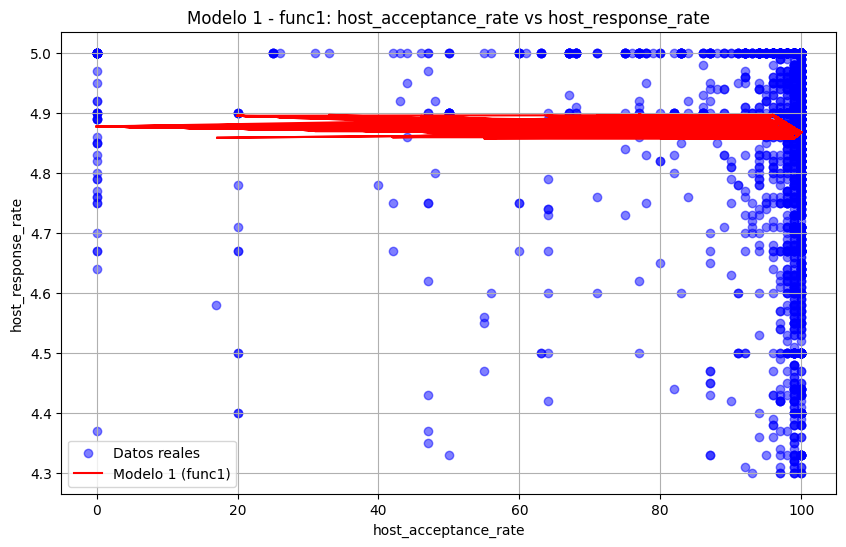

In [155]:
# Gráfica para el Modelo 1 (func1)
plt.figure(figsize=(10,6))
plt.scatter(x, y, label="Datos reales", color="blue", alpha=0.5)
plt.plot(x, y_pred1, color="red", label="Modelo 1 (func1)")
plt.title("Modelo 1 - func1: host_acceptance_rate vs host_response_rate")
plt.xlabel("host_acceptance_rate")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()

In [156]:
# Imprimir resultados
print("Parámetros:", parametros1)
print("R²:", r2_1)
print("Correlación:", corr_1)
print()

Parámetros: [0.01952069 4.87680618 1.        ]
R²: 0.00276302653191296
Correlación: 0.0525644987792761



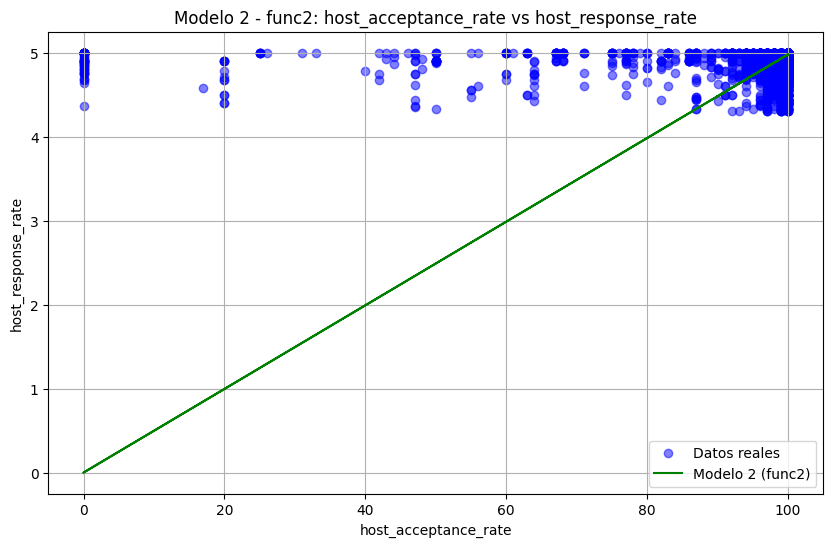

In [157]:
# Gráfica para el Modelo 2 (func2)
plt.figure(figsize=(10,6))
plt.scatter(x, y, label="Datos reales", color="blue", alpha=0.5)
plt.plot(x, y_pred2, color="green", label="Modelo 2 (func2)")
plt.title("Modelo 2 - func2: host_acceptance_rate vs host_response_rate")
plt.xlabel("host_acceptance_rate")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()

In [158]:
print("Parámetros:", parametros2)
print("R²:", r2_2)
print("Correlación:", corr_2)

Parámetros: [20.08715886  1.          1.        ]
R²: -22.64533069014239
Correlación: 0.004648629849613759


# Segunda correlación: host_acceptance_rate vs reviews_per_month


In [159]:
# Redefinir las variables
x2 = data['host_acceptance_rate'].values
y2 = data['reviews_per_month'].values

In [160]:
# Modelo 1
parametros1_v2, _ = curve_fit(func1, x2, y2)
y_pred1_v2 = func1(x2, *parametros1_v2)
r3 = r2_score(y2, y_pred1_v2)
corr3 = np.corrcoef(y2, y_pred1_v2)[0, 1]

In [161]:
# Modelo 2
parametros2_v2, _ = curve_fit(func3, x2, y2)
y_pred2_v2 = func3(x2, *parametros2_v2)
r3_2 = r2_score(y2, y_pred2_v2)
corr3_2 = np.corrcoef(y2, y_pred2_v2)[0, 1]

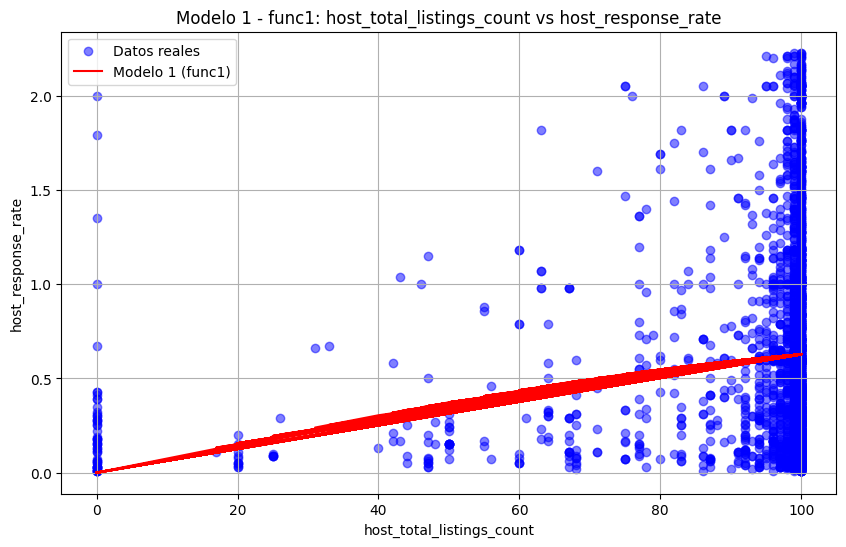

In [162]:
# Gráfica modelo 1
plt.figure(figsize=(10,6))
plt.scatter(x2, y2, label="Datos reales", color="blue", alpha=0.5)
plt.plot(x2, y_pred1_v2, color="red", label="Modelo 1 (func1)")
plt.title("Modelo 1 - func1: host_total_listings_count vs host_response_rate")
plt.xlabel("host_total_listings_count")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()

In [163]:
print("Parámetros:", parametros1_v2)
print("R²:", r3)
print("Correlación:", corr3)
print()

Parámetros: [-5.58990885e-04  2.76857626e+01  3.52073235e+03]
R²: 0.014372648047560777
Correlación: 0.1297000579849274



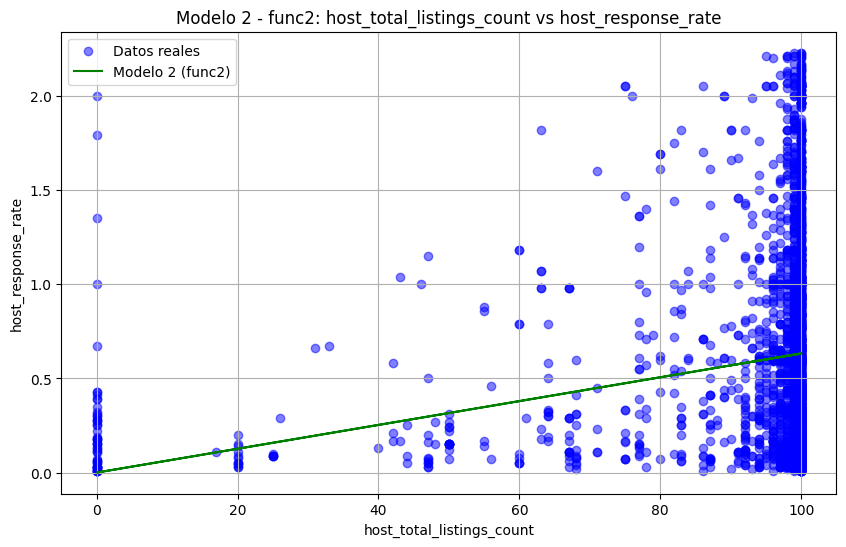

In [164]:
# Gráfica modelo 2
plt.figure(figsize=(10,6))
plt.scatter(x2, y2, label="Datos reales", color="blue", alpha=0.5)
plt.plot(x2, y_pred2_v2, color="green", label="Modelo 2 (func2)")
plt.title("Modelo 2 - func2: host_total_listings_count vs host_response_rate")
plt.xlabel("host_total_listings_count")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()

In [165]:
print("Parámetros:", parametros2_v2)
print("R²:", r3_2)
print("Correlación:", corr3_2)

Parámetros: [-141.42071064   70.71351786   70.71351786]
R²: 0.01370130299264416
Correlación: 0.131608361300422


# Tercera correlación: host_total_listings_count vs review_scores_rating

In [166]:
# Redefinir variables: ahora X será reviews_per_month y Y será price
x4 = data['host_total_listings_count'].values
y4 = data['review_scores_rating'].values

In [167]:
# Modelo 1
param_3, _ = curve_fit(func4, x4, y4)
y_pred_3 = func4(x4, *param_3)
r4 = r2_score(y4, y_pred_3)
corr4 = np.corrcoef(y4, y_pred_3)[0, 1]

/var/folders/cr/23ck8vtn1kd8mbhg9wssxh440000gn/T/ipykernel_1046/2996842689.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  param_3, _ = curve_fit(func4, x4, y4)


In [168]:
# Modelo 2
param_3_2, _ = curve_fit(func6, x4, y4)
y_pred_3_2 = func6(x4, *param_3_2)
r4_2 = r2_score(y4, y_pred_3_2)
corr4_2 = np.corrcoef(y4, y_pred_3_2)[0, 1]

/var/folders/cr/23ck8vtn1kd8mbhg9wssxh440000gn/T/ipykernel_1046/3035304546.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  param_3_2, _ = curve_fit(func6, x4, y4)


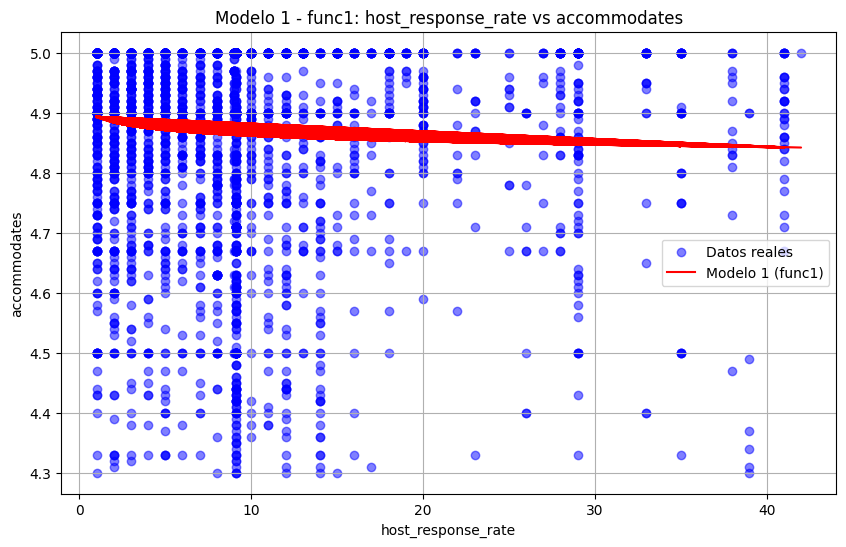

In [169]:
# Modelo 1
plt.figure(figsize=(10,6))
plt.scatter(x4, y4, label="Datos reales", color="blue", alpha=0.5)
plt.plot(x4, y_pred_3, color="red", label="Modelo 1 (func1)")
plt.title("Modelo 1 - func1: host_response_rate vs accommodates")
plt.xlabel("host_response_rate")
plt.ylabel("accommodates")
plt.legend()
plt.grid(True)
plt.show()


In [170]:
print("Parámetros:", param_3)
print("R²:", r4)
print("Correlación:", corr4)
print()

Parámetros: [-0.01369908  4.89294315  1.        ]
R²: 0.005766215670823693
Correlación: 0.07593560212985478



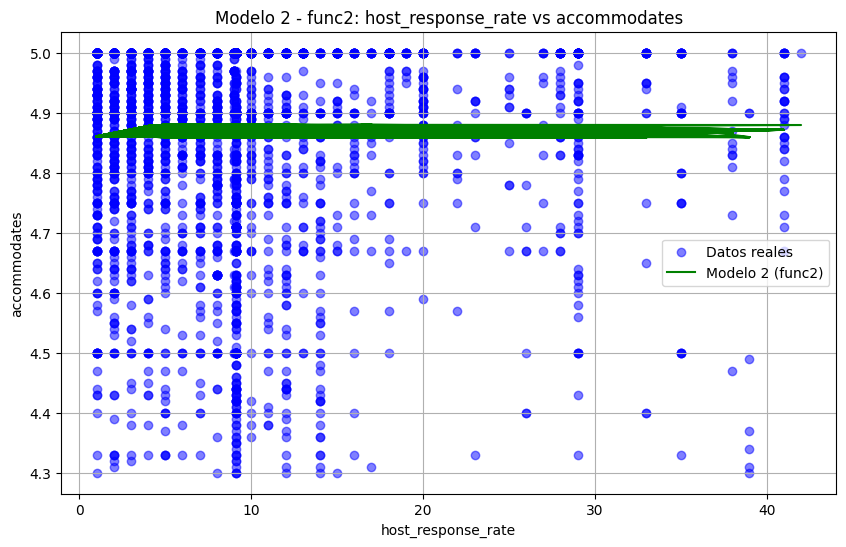

In [171]:
# Modelo 2
plt.figure(figsize=(10,6))
plt.scatter(x4, y4, label="Datos reales", color="blue", alpha=0.5)
plt.plot(x4, y_pred_3_2, color="green", label="Modelo 2 (func2)")
plt.title("Modelo 2 - func2: host_response_rate vs accommodates")
plt.xlabel("host_response_rate")
plt.ylabel("accommodates")
plt.legend()
plt.grid(True)
plt.show()

In [172]:
print("Parámetros:", param_3_2)
print("R²:", r4_2)
print("Correlación:", corr4_2)

Parámetros: [-0.01070809  4.86945838  1.        ]
R²: 0.0018217207424088278
Correlación: 0.04268162066289163


# Cuarta correlacion: correlacion acommodates vs reviews_per_month

In [173]:
x_5 = data['acommodates']
y_5 = data['reviews_per_month']
########### ESTA CORRELACION NO SE PUEDE REALIZAR DEBIDO A QUE LA COLUMNA ACOMMODATES NO ESTA EN MI BASE DE DATOS ##################

KeyError: 'acommodates'

# Quinta Correlacion: reviews_per_month vs price

In [174]:
x_6 = data['reviews_per_month']
y_6 = data['review_scores_value']

In [175]:
# Eliminar valores nulos de forma directa usando dropna
valores_validos = pd.concat([x_6, y_6], axis=1).dropna()
x_6 = valores_validos['reviews_per_month'].values
y_6 = valores_validos['review_scores_value'].values

In [176]:
# Modelo 1
param_7, _ = curve_fit(func4, x_6, y_6)
y_pred7 = func4(x_6, *param_7)
r2_5 = r2_score(y_6, y_pred7)
corr_5 = np.corrcoef(y_6, y_pred7)[0, 1]

/var/folders/cr/23ck8vtn1kd8mbhg9wssxh440000gn/T/ipykernel_1046/1492602965.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  param_7, _ = curve_fit(func4, x_6, y_6)


In [177]:
# Modelo 2
param_quad_actual, _ = curve_fit(func6, x_6, y_6)
y_pred7_2 = func6(x_6, *param_quad_actual)
r2_5_2 = r2_score(y_6, y_pred7_2)
corr_5_2 = np.corrcoef(y_6, y_pred7_2)[0, 1]


/var/folders/cr/23ck8vtn1kd8mbhg9wssxh440000gn/T/ipykernel_1046/2670118400.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  param_quad_actual, _ = curve_fit(func6, x_6, y_6)


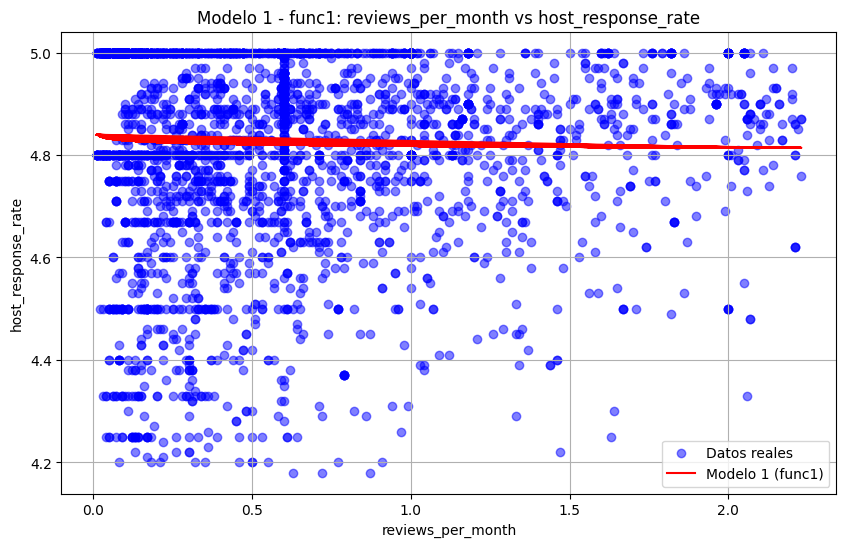

In [178]:
# Gráfica modelo 1
plt.figure(figsize=(10,6))
plt.scatter(x_6, y_6, label="Datos reales", color="blue", alpha=0.5)
plt.plot(x_6, y_pred7, color="red", label="Modelo 1 (func1)")
plt.title("Modelo 1 - func1: reviews_per_month vs host_response_rate")
plt.xlabel("reviews_per_month")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()

In [179]:
print("Parámetros:", param_7)
print("R²:", r2_5)
print("Correlación:", corr_5)
print()

Parámetros: [-4.74162863e-03  4.81776003e+00  1.00000000e+00]
R²: 0.0007764301211522495
Correlación: 0.027864495709639555



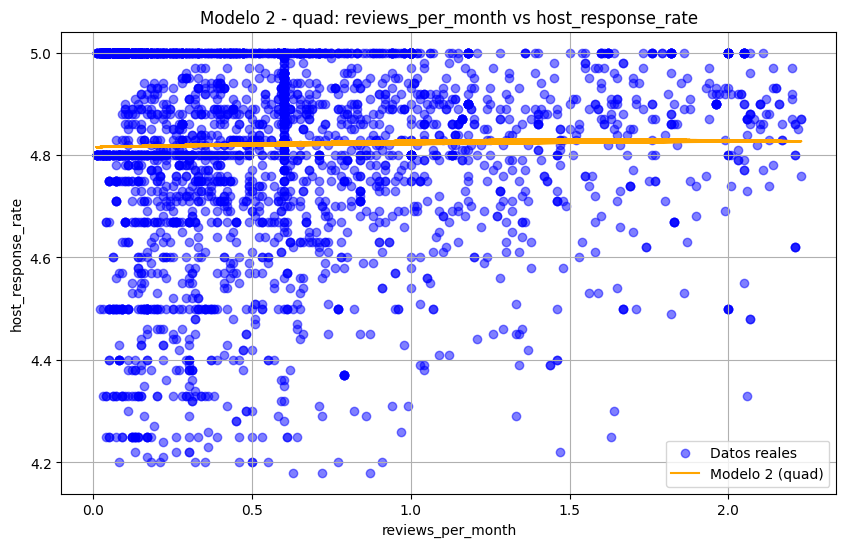

In [180]:
# Gráfica modelo 2
plt.figure(figsize=(10,6))
plt.scatter(x_6, y_6, label="Datos reales", color="blue", alpha=0.5)
plt.plot(x_6, y_pred7_2, color="orange", label="Modelo 2 (quad)")
plt.title("Modelo 2 - quad: reviews_per_month vs host_response_rate")
plt.xlabel("reviews_per_month")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()

In [181]:
print("Parámetros:", param_quad_actual)
print("R²:", r2_5_2)
print("Correlación:", corr_5_2)

Parámetros: [0.01482464 4.81529854 1.        ]
R²: 0.0006050372256731773
Correlación: 0.024597504460275473


# Sexta correlacion: price vs review_scores_rating

In [182]:
x_7 = data['price']
y_7 = data['review_scores_rating']

In [183]:
# Modelo 1
param_8, _ = curve_fit(func4, x_7, y_7)
y_pred_8 = func4(x_7, *param_8)
r2_8 = r2_score(y_7, y_pred_8)
corr_8 = np.corrcoef(y_7, y_pred_8)[0, 1]

/var/folders/cr/23ck8vtn1kd8mbhg9wssxh440000gn/T/ipykernel_1046/3172886611.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  param_8, _ = curve_fit(func4, x_7, y_7)


In [184]:
# Modelo 2
param_8_2, _ = curve_fit(func5, x_7, y_7)
y_pred_8_2 = func5(x_7, *param_8_2)
r2_8_2 = r2_score(y_7, y_pred_8_2)
corr_8_2 = np.corrcoef(y_7, y_pred_8_2)[0, 1]

/var/folders/cr/23ck8vtn1kd8mbhg9wssxh440000gn/T/ipykernel_1046/2023823659.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  param_8_2, _ = curve_fit(func5, x_7, y_7)


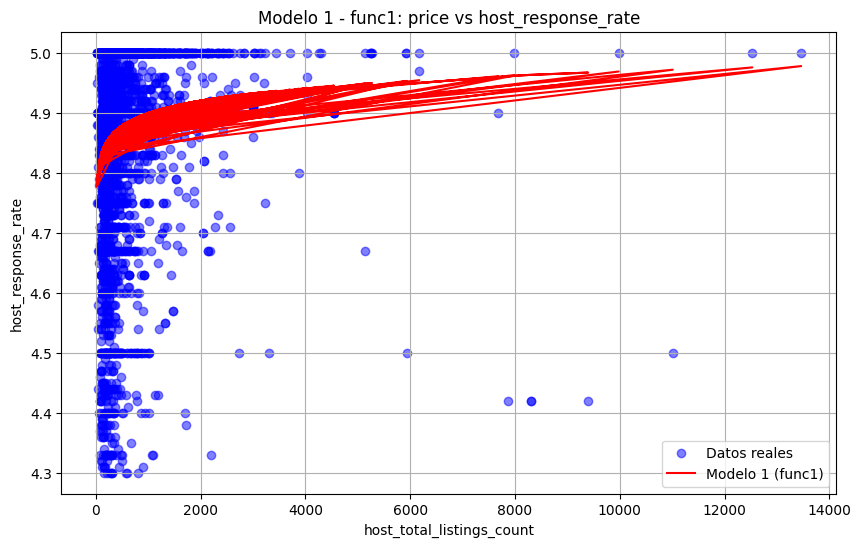

In [185]:
# Gráfica modelo 1
plt.figure(figsize=(10,6))
plt.scatter(x_7, y_7, label="Datos reales", color="blue", alpha=0.5)
plt.plot(x_7, y_pred_8, color="red", label="Modelo 1 (func1)")
plt.title("Modelo 1 - func1: price vs host_response_rate")
plt.xlabel("host_total_listings_count")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()

In [186]:
print("Parámetros:", param_8)
print("R²:", r2_8)
print("Correlación:", corr_8)
print()

Parámetros: [0.03016277 4.69072758 1.        ]
R²: 0.024776065477477904
Correlación: 0.1574041469513367



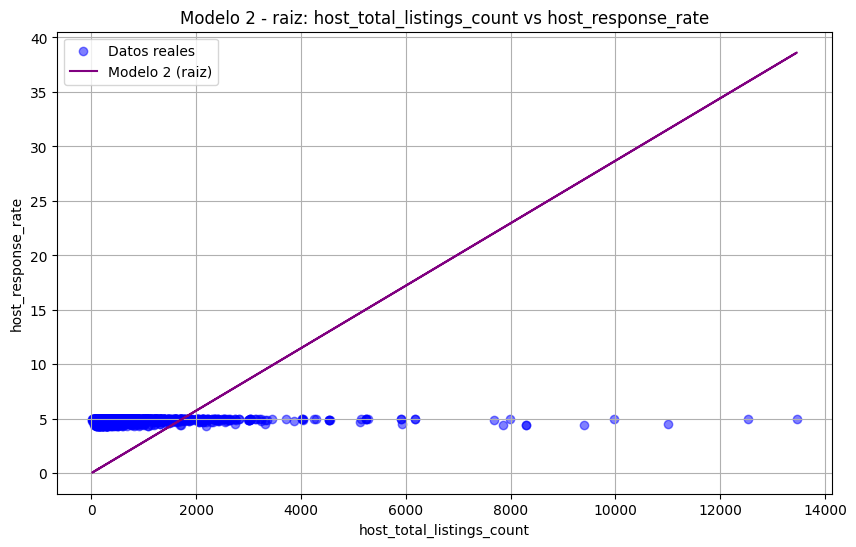

In [187]:
# Gráfica modelo 2
plt.figure(figsize=(10,6))
plt.scatter(x_7, y_7, label="Datos reales", color="blue", alpha=0.5)
plt.plot(x_7, y_pred_8_2, color="purple", label="Modelo 2 (raiz)")
plt.title("Modelo 2 - raiz: host_total_listings_count vs host_response_rate")
plt.xlabel("host_total_listings_count")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()

In [188]:
print("Parámetros:", param_8_2)
print("R²:", r2_8_2)
print("Correlación:", corr_8_2)

Parámetros: [348.65439979   1.           1.        ]
R²: -567.1349776626323
Correlación: 0.0751945676607177


# Tabla de correlacion

In [ ]:
# Crear una tabla resumen con los resultados de los análisis realizados

resumen_resultados = pd.DataFrame([
    {##################################################################### ej1 
        "Variable dependiente": "host_response_rate",
        "Variable independiente": "review_scores_rating",
        "Modelo": "func3",
        "R²": r2_1,
        "Correlación": corr_1
    },
    {
        "Variable dependiente": "host_response_rate",
        "Variable independiente": "review_scores_rating",
        "Modelo": "func2",
        "R²": r2_2,
        "Correlación": corr_2
    },
    {####################################################################### ej2 
        "Variable dependiente": "host_acceptance_rate",
        "Variable independiente": "reviews_per_month",
        "Modelo": "func1",
        "R²": r3,
        "Correlación": corr3
    },
    {
        "Variable dependiente": "host_acceptance_rate",
        "Variable independiente": "reviews_per_month",
        "Modelo": "func3",
        "R²": r3_2,
        "Correlación": corr3_2
    },
    {######################################################################### ej3
        "Variable dependiente": "host_total_listings_count",
        "Variable independiente": "review_scores_rating",
        "Modelo": "func4",
        "R²": r4,
        "Correlación": corr4
    },
    {
        "Variable dependiente": "host_total_listings_count",
        "Variable independiente": "review_scores_rating",
        "Modelo": "func6",
        "R²": r4_2,
        "Correlación": corr4_2
    },
    {######################################################################### ej4 NO SE PUEDE
        "Variable dependiente": "acommodates",
        "Variable independiente": "reviews_per_month",
        "Modelo": "NaN",
        "R²": "NaN",
        "Correlación": "NaN"
    },
    {
        "Variable dependiente": "acommodates",
        "Variable independiente": "reviews_per_month",
        "Modelo": "NaN",
        "R²": "NaN",
        "Correlación": "NaN"
    },
    {####################################################################### ej5 
        "Variable dependiente": "reviews_per_month",
        "Variable independiente": "price",
        "Modelo": "func4",
        "R²": r2_5,
        "Correlación": corr_5,
    },
    {
        "Variable dependiente": "reviews_per_month",
        "Variable independiente": "price",
        "Modelo": "func6",
        "R²": r2_5_2,
        "Correlación": corr_5_2
    },
        {####################################################################### ej6 
        "Variable dependiente": "price",
        "Variable independiente": "review_scores_rating",
        "Modelo": "func2",
        "R²": r2_8,
        "Correlación": corr_8
    },
    {
        "Variable dependiente": "price",
        "Variable independiente": "review_scores_rating",
        "Modelo": "func5",
        "R²": r2_8_2,
        "Correlación": corr_8_2
    }
])

resumen_resultados

,Variable dependiente,Variable independiente,Modelo,R²,Correlación
0,host_response_rate,review_scores_rating,func3,0.002763,0.052564
1,host_response_rate,review_scores_rating,func2,-22.645331,0.004649
2,host_acceptance_rate,reviews_per_month,func1,0.014373,0.1297
3,host_acceptance_rate,reviews_per_month,func3,0.013701,0.131608
4,host_total_listings_count,review_scores_rating,func4,0.005766,0.075936
5,host_total_listings_count,review_scores_rating,func6,0.001822,0.042682
6,acommodates,reviews_per_month,NaN,NaN,NaN
7,acommodates,reviews_per_month,NaN,NaN,NaN
8,reviews_per_month,price,func4,0.000776,0.027864
9,reviews_per_month,price,func6,0.000605,0.024598
